# EU-OS bioactives → SpatialData

`eu_os_bioactives_to_anndata.ipynb` stops at a well × CellProfiler-feature table. This
notebook builds the other half of the picture for the same dataset: a
[SpatialData](https://spatialdata.scverse.org/) object that also carries the **field-of-view
images** and **per-object segmentation masks**, wired together by **coordinate systems** so
that every FOV and every cell can be placed in one shared per-well frame.

It is a deliberately small, exemplary object — four wells of one
[EU-OPENSCREEN bioactives](https://github.com/schmiedc/EU-OS_bioactives) plate
(`IMTM` / HepG2 / library plate `B1001`, replicate `R1`) — chosen to exercise the design:

| SpatialData element | holds | here |
|---|---|---|
| `images`   | raw FOVs | 4 wells × 9 fields × 4 channels, 1000×1000 px `uint16` |
| `labels`   | pixel segmentation (CellProfiler is pixel-based) | `nuclei` + `cells` per field, from scikit-image |
| `tables`   | feature matrices | `profiles` (well × ~2800 CP features) + `nuclei` (object × morphology) |
| `shapes`   | well outlines for the plate map | 4 circles in the `plate` frame |

The raw images and the Yokogawa CV8000 acquisition metadata come from the
[Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/)
(`cpg0036-EU-OS-bioactives`, public S3, no credentials); the well-level profiles come from
[Zenodo](https://doi.org/10.5281/zenodo.13309566) as in the sister notebook. **No
segmentation is published for this dataset**, so we produce a quick one here — good enough to
demonstrate the container, not a substitute for the CellProfiler pipeline.

The sanity-check sections then ask the questions the design notes raise, most of all:
*does transforming per-FOV elements into a shared well coordinate system actually work?*

In [1]:
from __future__ import annotations

import io
import logging
import subprocess
import warnings
import xml.etree.ElementTree as ET
import zipfile
from collections.abc import Sequence
from pathlib import Path
from urllib.request import urlopen

import anndata as ad
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import s3fs
import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the .pl accessor)
import tifffile
from matplotlib.colors import Normalize
from scipy import ndimage as ndi
from shapely.geometry import Point
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import regionprops_table
from skimage.morphology import remove_small_objects
from skimage.segmentation import expand_labels, watershed
from spatialdata.models import Image2DModel, Labels2DModel, ShapesModel, TableModel
from spatialdata.transformations import Identity, Translation, get_transformation
from spatialdata.transformations import Sequence as TSequence

warnings.filterwarnings("ignore")  # skimage / ome-zarr / anndata chatter
logging.getLogger("ome_zarr").setLevel(logging.ERROR)  # silence "no parent found" on read_zarr

DATA_ROOT = Path("~/data/eu-os-bioactives").expanduser()
CACHE = DATA_ROOT / "images_cache"
CACHE.mkdir(parents=True, exist_ok=True)
ZARR_PATH = DATA_ROOT / "eu_os_imtm_b1001r1.zarr"

# --- Cell Painting Gallery layout for this plate (IMTM / B1001 / R1) ---------
BUCKET = "cellpainting-gallery"
PREFIX = "cpg0036-EU-OS-bioactives/IMTM"
BATCH_DIR = "2022_05_20_Batch7_HepG2"
IMG_DIR = f"{PREFIX}/images/{BATCH_DIR}/images/Bioactives_1_plate_1"
LOAD_DATA = f"{PREFIX}/workspace/load_data_csv/{BATCH_DIR}/B1001_R1/load_data.csv"
BTS = "{http://www.yokogawa.co.jp/BTS/BTSSchema/1.0}"

# --- Zenodo profile + annotation tables (shared with the AnnData notebook) ---
ZENODO = "https://zenodo.org/api/records/13309566/files"
PLATE, REPLICATE = "B1001", "R1"
PROFILE_CSV = DATA_ROOT / "aggregated_data/IMTM_HepG2/2023-07-06_HepG2_10uM_B1001_R1_CP_Profiles_Aggregated.csv"
ANN_DIR = DATA_ROOT / "annotations"
ANNOTATION_CSV = ANN_DIR / "2023-08-14_Annotation2_IMTM_HepG2.csv"

CHANNELS = ("DNA", "ER", "AGP", "Mito")  # Yokogawa Ch 1..4 -> file tokens C01..C04
WELL_PITCH_UM = 4500.0  # CellCarrier-384-Ultra Column/RowPitch, from the .wpp
WELL_RADIUS_UM = 1850.0
POSITIVE_CONTROLS = ("Nocodazole", "Tetrandrine")
WELLS = ["A23", "C23", "A01", "A05"]  # negcon / poscon / tubulin-binder trt / cytotoxic trt

fs = s3fs.S3FileSystem(anon=True)


def s3_bytes(key: str) -> bytes:
    """Fetch an S3 object once, then serve it from the local cache."""
    p = CACHE / key.replace("/", "__")
    if not p.exists():
        p.write_bytes(fs.cat_file(f"{BUCKET}/{key}"))
    return p.read_bytes()


def well_row_col(well: str) -> tuple[int, int]:
    return ord(well[0]) - 64, int(well[1:])

/Users/luisheinzlmeier/Desktop/cellpainting/WS1/cell-painting-io/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Well × feature table

The `profiles` table is exactly the object the AnnData notebook builds, restricted to one
replicate plate and the four wells we image below. Because everything here is one plate, the
per-plate `mad_robustize` against the DMSO wells is self-contained: subtract the DMSO median,
divide by the DMSO MAD, feature by feature. Raw medians stay in `layers["aggregated"]`.

In [2]:
def fetch_zip(name: str, marker: str) -> None:
    """Download+unpack a Zenodo archive unless `marker` already exists under DATA_ROOT."""
    if (DATA_ROOT / marker).exists():
        return
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"fetching {name} (one-time)")
    with urlopen(f"{ZENODO}/{name}/content") as resp:  # Zenodo, https only
        payload = resp.read()
    with zipfile.ZipFile(io.BytesIO(payload)) as zf:
        zf.extractall(DATA_ROOT)


def _split_plate_replicate(df: pd.DataFrame) -> pd.DataFrame:
    parts = df["Metadata_Plate"].astype(str).str.rsplit("_", n=1, expand=True)
    return df.assign(Metadata_Plate=parts[0].to_numpy(), Metadata_Replicate=parts[1].to_numpy())


def mad_robustize(x: np.ndarray, ref: np.ndarray) -> np.ndarray:
    med = np.median(ref, axis=0)
    mad = np.median(np.abs(ref - med), axis=0) * 1.4826
    return (x - med) / np.where(mad == 0, np.nan, mad)


def annotate_features(var: pd.DataFrame) -> pd.DataFrame:
    compartments = {"Nuc": "Nuclei", "Cells": "Cells", "Cyto": "Cytoplasm"}
    lookup = {c.lower(): c for c in CHANNELS}
    tokens = [n.split("_") for n in var.index]
    matched = [[lookup[t.lower()] for t in tok if t.lower() in lookup] for tok in tokens]
    var["compartment"] = pd.Categorical([compartments[t[0]] for t in tokens])
    var["family"] = pd.Categorical([t[1] if len(t) > 1 else "" for t in tokens])
    var["channel"] = pd.Categorical([m[0] if m else None for m in matched])
    return var


def build_profiles(wells: Sequence[str]) -> ad.AnnData:
    fetch_zip("Aggregated_Profiles.zip", "aggregated_data/IMTM_HepG2")
    fetch_zip("Profile_Analysis.zip", "annotations")

    df = _split_plate_replicate(pd.read_csv(PROFILE_CSV))
    feats = [c for c in df.columns if c.split("_", 1)[0] in ("Nuc", "Cells", "Cyto")]
    drop = ("BoundingBox", "Center_X", "Center_Y", "Location", "ObjectNumber", "Parent", "Children", "Number_")
    feats = [c for c in feats if not any(tok in c for tok in drop)]

    ann = pd.read_csv(ANNOTATION_CSV).rename(
        columns={"Metadata_Well": "Well", "Metadata_EOS": "EOS", "Metadata_Concentration": "concentration_uM"}
    )
    ann = ann[ann.Metadata_Plate.eq(PLATE) & ann.Metadata_Batch.eq(REPLICATE)][["Well", "EOS", "concentration_uM"]]

    eos_pdid = pd.read_csv(ANN_DIR / "2024-08-02_EOS_pdid.csv").rename(
        columns={"Metadata_EOS": "EOS", "Metadata_pdid": "pdid"}
    )
    compounds = pd.read_csv(ANN_DIR / "pd_export_04_2022_2464_compounds_standardized.csv")[
        ["pdid", "name", "mw", "logp"]
    ].rename(columns={"name": "compound"})
    tubulin = pd.read_csv(ANN_DIR / "2024-08-02_Tubulin.csv").rename(
        columns={"Metadata_pdid": "pdid", "Metadata_tubulin": "tubulin_binder"}
    )
    cmpd = (
        eos_pdid.merge(compounds, on="pdid", how="left")
        .merge(tubulin, on="pdid", how="left")
        .drop_duplicates("EOS")
        .set_index("EOS")
    )

    obs = pd.DataFrame(
        {
            "Plate": df.Metadata_Plate.to_numpy(),
            "Replicate": df.Metadata_Replicate.to_numpy(),
            "Well": df.Metadata_Well.to_numpy(),
            "cell_count": df.Metadata_Object_Count.to_numpy(),
        }
    ).merge(ann, on="Well", how="left")
    obs["pert_type"] = pd.Categorical(
        np.where(obs.EOS.eq("DMSO"), "negcon", np.where(obs.EOS.isin(POSITIVE_CONTROLS), "poscon", "trt")),
        categories=["negcon", "poscon", "trt"],
    )
    obs = obs.join(cmpd[["pdid", "compound", "mw", "logp", "tubulin_binder"]], on="EOS")
    obs["compound"] = obs["compound"].astype("string").fillna(obs["EOS"])
    obs["tubulin_binder"] = obs["tubulin_binder"].fillna(False).astype(bool)
    obs.index = pd.Index(obs.Well, name="well")

    x_raw = df[feats].to_numpy(np.float64)
    x_norm = mad_robustize(x_raw, x_raw[obs.pert_type.eq("negcon").to_numpy()])
    finite = np.isfinite(x_norm).all(axis=0)
    adata = ad.AnnData(
        X=x_norm[:, finite].astype(np.float32),
        obs=obs,
        var=annotate_features(pd.DataFrame(index=pd.Index(np.array(feats)[finite], name="feature"))),
        layers={"aggregated": x_raw[:, finite].astype(np.float32)},
    )
    return adata[adata.obs.Well.isin(wells)].copy()


profiles = build_profiles(WELLS)
profiles.obs[["Well", "EOS", "compound", "concentration_uM", "pert_type", "cell_count", "tubulin_binder"]]

,Well,EOS,compound,concentration_uM,pert_type,cell_count,tubulin_binder
well,,,,,,,
A01,A01,EOS100001,vincristine,10,trt,401,True
A05,A05,EOS100017,AMSACRINE,10,trt,91,False
A23,A23,DMSO,DMSO,0,negcon,1244,False
C23,C23,Nocodazole,Nocodazole,5,poscon,493,False


## 2 · Images and stage positions

The plate was acquired on a Yokogawa **CV8000** (20× water, `0.6492 µm/px`, 1000×1000 px),
**9 fields per well** on a 3×3 grid, four fluorescence channels. Two files in the image
folder describe the geometry:

* `MeasurementDetail.mrf` — pixel size, image size, channel list.
* `MeasurementData.mlf` — one record per (well, field, channel): the **stage X/Y in µm** and
  the TIFF filename.

This is the metadata that lets us put every FOV in the right place. `load_data.csv` (the
CellProfiler index) additionally maps each `URL_Orig<channel>` to its S3 path, confirming the
channel ↔ file-token wiring.

In [3]:
def parse_yokogawa(mlf: bytes, mrf: bytes) -> tuple[pd.DataFrame, float]:
    px = float(ET.fromstring(mrf).findall(f"{BTS}MeasurementChannel")[0].get(f"{BTS}HorizontalPixelDimension"))
    rows = [
        {
            "well": f"{chr(64 + int(r.get(f'{BTS}Row')))}{int(r.get(f'{BTS}Column')):02d}",
            "field": int(r.get(f"{BTS}FieldIndex")),
            "ch": int(r.get(f"{BTS}Ch")),
            "x_um": float(r.get(f"{BTS}X")),
            "y_um": float(r.get(f"{BTS}Y")),
            "file": r.text.strip(),
        }
        for r in ET.fromstring(mlf).findall(f"{BTS}MeasurementRecord")
        if r.get(f"{BTS}Type") == "IMG"
    ]
    return pd.DataFrame(rows), px


records, px_um = parse_yokogawa(
    s3_bytes(f"{IMG_DIR}/MeasurementData.mlf"), s3_bytes(f"{IMG_DIR}/MeasurementDetail.mrf")
)
records = records[records.well.isin(WELLS)].reset_index(drop=True)

fov_um = 1000 * px_um
grid = records[records.well == "A23"].groupby("field")[["x_um", "y_um"]].first()
print(f"pixel size {px_um:.4f} um/px   FOV {fov_um:.0f} um   fields {sorted(records.field.unique())}")
print(
    f"stage-position grid spacing: {np.unique(np.diff(sorted(grid.x_um.unique())))} um  "
    f"=> {np.unique(np.diff(sorted(grid.x_um.unique()))) - fov_um} um gap between FOVs"
)
grid

pixel size 0.6492 um/px   FOV 649 um   fields [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
stage-position grid spacing: [945.] um  => [295.77906512] um gap between FOVs


,x_um,y_um
field,,
1,-945.0,945.0
2,0.0,945.0
3,945.0,945.0
4,945.0,0.0
5,0.0,0.0
6,-945.0,0.0
7,-945.0,-945.0
8,0.0,-945.0
9,945.0,-945.0


## 3 · Segmentation

No masks ship with this dataset, so we make a fast one with scikit-image: smooth the DNA
channel, Otsu-threshold, split touching nuclei by a distance-transform watershed, then grow
cell bodies from the nuclei over an ER+AGP mask. Labels go in as `uint16` (a few hundred
objects per field). This is a stand-in to populate `labels` — the published study uses a
tuned CellProfiler pipeline.

In [4]:
def load_field(recs: pd.DataFrame, well: str, field: int) -> np.ndarray:
    """(c, y, x) uint16 stack in CHANNELS order."""
    sub = recs[(recs.well == well) & (recs.field == field)].sort_values("ch")
    return np.stack([tifffile.imread(io.BytesIO(s3_bytes(f"{IMG_DIR}/{f}"))) for f in sub.file]).astype(np.uint16)


def segment_field(img: np.ndarray, min_px: int = 60) -> tuple[np.ndarray, np.ndarray]:
    dna = gaussian(img[0].astype(np.float32), sigma=2, preserve_range=True)
    fg = remove_small_objects(dna > threshold_otsu(dna), max_size=min_px)
    dist = ndi.distance_transform_edt(fg)
    peaks = peak_local_max(dist, min_distance=8, labels=fg, footprint=np.ones((3, 3)))
    markers = np.zeros(fg.shape, np.int32)
    markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)
    nuclei = watershed(-dist, markers, mask=fg)
    body = gaussian(img[1].astype(np.float32) + img[2].astype(np.float32), sigma=3, preserve_range=True)
    mask = (body > threshold_otsu(body)) | (nuclei > 0)
    cells = watershed(-body, nuclei, mask=mask)
    if cells.max() == 0:  # degenerate (e.g. a near-empty cytotoxic field)
        cells = expand_labels(nuclei, distance=15)
    return nuclei.astype(np.uint16), cells.astype(np.uint16)


_demo = load_field(records, "A23", 5)
_n, _c = segment_field(_demo)
print(f"A23 F5: {_demo.shape} {_demo.dtype}   nuclei={_n.max()}   cells={_c.max()}")

A23 F5: (4, 1000, 1000) uint16   nuclei=177   cells=177


## 4 · Assemble the SpatialData object — one well at a time

`build_well` returns a self-contained `SpatialData` for a single well. Every field gets:

* an **image** `"{well}_F{f}_image"` and two **labels** `"{well}_F{f}_nuclei"` / `"_cells"`;
* two transformations, sharing one anchor:
  * to the **`{well}`** coordinate system — a `Translation` by the field's stage offset
    (converted µm → px, with the Y axis flipped: stage Y points up, image rows point down);
  * to the **`plate`** coordinate system — the same, then a further `Translation` by the
    well's nominal centre (`4.5 mm` pitch).

Objects are also summarised into a `nuclei` table (`region_key`/`instance_key` point each row
at its label in its field), demonstrating the "objects → `labels`, measurements → `tables`"
split from the design notes.

Building per-well and then `spatialdata.concatenate`-ing is the whole composability story:
the same call would stack two *plates* if the element keys and coordinate-system names stay
disjoint (they are prefixed by well here; prefix by plate for a multi-plate object).

In [5]:
def build_well(recs: pd.DataFrame, px: float, well: str) -> sd.SpatialData:
    wr, wc = well_row_col(well)
    pos = recs[recs.well == well].groupby("field")[["x_um", "y_um"]].first()
    x0, y1 = pos.x_um.min(), pos.y_um.max()
    plate_off = np.array([(wc - 1) * WELL_PITCH_UM, (wr - 1) * WELL_PITCH_UM]) / px

    images, labels, tabs = {}, {}, []
    for f in pos.index:
        img = load_field(recs, well, f)
        nuc, cell = segment_field(img)
        off = np.array([(pos.loc[f, "x_um"] - x0) / px, (y1 - pos.loc[f, "y_um"]) / px])
        well_t = Translation(off, axes=("x", "y"))
        tfs = {well: well_t, "plate": TSequence([well_t, Translation(plate_off, axes=("x", "y"))])}
        images[f"{well}_F{f}_image"] = Image2DModel.parse(
            img, dims=("c", "y", "x"), c_coords=list(CHANNELS), transformations=dict(tfs)
        )
        labels[f"{well}_F{f}_nuclei"] = Labels2DModel.parse(nuc, dims=("y", "x"), transformations=dict(tfs))
        labels[f"{well}_F{f}_cells"] = Labels2DModel.parse(cell, dims=("y", "x"), transformations=dict(tfs))
        rp = pd.DataFrame(
            regionprops_table(nuc, img[0], properties=("label", "centroid", "area", "eccentricity", "intensity_mean"))
        )
        rp["x_well_um"] = (rp["centroid-1"] + off[0]) * px
        rp["y_well_um"] = (rp["centroid-0"] + off[1]) * px
        rp["region"], rp["well"], rp["field"] = f"{well}_F{f}_nuclei", well, f
        tabs.append(rp)

    obj = pd.concat(tabs, ignore_index=True)
    feats = ["area", "eccentricity", "intensity_mean"]
    nuc_ad = ad.AnnData(
        X=obj[feats].to_numpy(np.float32),
        obs=obj[["region", "well", "field", "x_well_um", "y_well_um"]].reset_index(drop=True),
        var=pd.DataFrame(index=feats),
    )
    nuc_ad.obs["instance_id"] = obj["label"].astype(np.int64).to_numpy()
    nuc_ad.obs_names = (obj["region"] + "-" + obj["label"].astype(str)).to_numpy()
    nuc_ad.obs["region"] = nuc_ad.obs["region"].astype("category")
    nuc_tab = TableModel.parse(
        nuc_ad, region=sorted(obj.region.unique()), region_key="region", instance_key="instance_id"
    )
    return sd.SpatialData(images=images, labels=labels, tables={"nuclei": nuc_tab})


def well_outline_shapes(wells: Sequence[str], px: float) -> gpd.GeoDataFrame:
    rows = [
        {
            "well": w,
            "geometry": Point(
                (well_row_col(w)[1] - 1) * WELL_PITCH_UM / px, (well_row_col(w)[0] - 1) * WELL_PITCH_UM / px
            ),
            "radius": WELL_RADIUS_UM / px,
        }
        for w in wells
    ]
    return gpd.GeoDataFrame(rows, geometry="geometry")

In [6]:
per_well = {w: build_well(records, px_um, w) for w in WELLS}

sdata = sd.concatenate(list(per_well.values()), concatenate_tables=True)
sdata["profiles"] = TableModel.parse(profiles)
sdata["well_outlines"] = ShapesModel.parse(well_outline_shapes(WELLS, px_um), transformations={"plate": Identity()})
sdata

SpatialData object
├── Images
│     ├── 'A01_F1_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F2_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F3_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F4_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F5_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F6_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F7_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F8_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A01_F9_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F1_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F2_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F3_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F4_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F5_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F6_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F7_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'A05_F8_image': DataArray[cyx] (4, 1000, 1000)
│

## Sanity check 1 · coordinate systems and the well transform

`coordinate_systems` should list one frame per well plus `plate`. Composing each field's
transform into its well frame must reproduce the 3×3 stage grid: origins at
`0 / 945 / 1890 µm` on both axes, i.e. FOV pitch `945 µm` with a `~296 µm` gap
(`945 − 649`) — no overlap, exactly as the CV8000 recorded it.

In [7]:
print("coordinate systems:", sdata.coordinate_systems)

rows = []
for k in sorted(k for k in sdata.images if k.startswith("A23_")):
    m = get_transformation(sdata.images[k], "A23").to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))
    rows.append({"field": k.split("_")[1], "x_um": round(m[0, 2] * px_um, 1), "y_um": round(m[1, 2] * px_um, 1)})
grid_cs = pd.DataFrame(rows)

x_spacing = np.diff(sorted(grid_cs.x_um.unique()))
y_spacing = np.diff(sorted(grid_cs.y_um.unique()))
assert np.allclose(x_spacing, 945.0, atol=1.0), x_spacing
assert np.allclose(y_spacing, 945.0, atol=1.0), y_spacing
assert np.allclose(x_spacing - fov_um, 945.0 - fov_um, atol=1.0)
print(f"FOV pitch {x_spacing[0]:.1f} um   gap {x_spacing[0] - fov_um:.1f} um   (assertions pass)")
grid_cs.set_index("field").T

coordinate systems: ['C23', 'A05', 'A23', 'plate', 'A01']
FOV pitch 945.0 um   gap 295.8 um   (assertions pass)


field,F1,F2,F3,F4,F5,F6,F7,F8,F9
x_um,0.0,945.0,1890.0,1890.0,945.0,0.0,0.0,945.0,1890.0
y_um,0.0,0.0,0.0,945.0,945.0,945.0,1890.0,1890.0,1890.0


## Sanity check 2 · objects from different FOVs land in one frame

The point of the well frame is that a cell in field 1 and a cell in field 2 get comparable
coordinates. Take the `nuclei` centroids (already carried in well-µm in the table), and check
that two horizontally adjacent fields form two separated clouds whose gap matches the FOV
gap — i.e. the objects tile, they don't pile up at the origin or overlap.

In [8]:
nt = sdata["nuclei"].obs
f1 = nt[(nt.well == "A23") & (nt.field == 1)]
f2 = nt[(nt.well == "A23") & (nt.field == 2)]
gap = f2.x_well_um.min() - f1.x_well_um.max()
assert f1.x_well_um.max() < f2.x_well_um.min(), "adjacent-FOV nuclei clouds overlap in the well frame"
print(f"A23 field 1 x: {f1.x_well_um.min():6.0f} .. {f1.x_well_um.max():6.0f} um   ({len(f1)} nuclei)")
print(f"A23 field 2 x: {f2.x_well_um.min():6.0f} .. {f2.x_well_um.max():6.0f} um   ({len(f2)} nuclei)")
print(f"inter-cloud gap {gap:.0f} um  (FOV gap {945.0 - fov_um:.0f} um + segmentation margins)")

A23 field 1 x:      4 ..    645 um   (223 nuclei)
A23 field 2 x:    948 ..   1589 um   (236 nuclei)
inter-cloud gap 304 um  (FOV gap 296 um + segmentation margins)


## Sanity check 3 · wells (and plates) concatenate

`sdata` above was already assembled with `spatialdata.concatenate`. Spell the contract out:
building each well independently and concatenating must be **additive** — element counts add,
tables stack, coordinate systems union — because the keys (`A23_*`, `C23_*`, …) and frame
names are disjoint. The identical mechanism joins two plates: give each plate its own element
prefix and its own `plate` frame name (or a shared `global` one), and `concatenate` them.

In [9]:
two = sd.concatenate([per_well["A23"], per_well["C23"]], concatenate_tables=True)
assert len(two.images) == len(per_well["A23"].images) + len(per_well["C23"].images)
assert len(two.labels) == len(per_well["A23"].labels) + len(per_well["C23"].labels)
assert two["nuclei"].n_obs == per_well["A23"]["nuclei"].n_obs + per_well["C23"]["nuclei"].n_obs
assert set(two.coordinate_systems) == {"A23", "C23", "plate"}
print(f"A23  {len(per_well['A23'].images):>2} images  {per_well['A23']['nuclei'].n_obs:>5} nuclei")
print(f"C23  {len(per_well['C23'].images):>2} images  {per_well['C23']['nuclei'].n_obs:>5} nuclei")
print(f"---> {len(two.images):>2} images  {two['nuclei'].n_obs:>5} nuclei   systems {two.coordinate_systems}")

A23   9 images   1915 nuclei
C23   9 images    778 nuclei
---> 18 images   2693 nuclei   systems ['A23', 'C23', 'plate']


## Sanity check 4 · Zarr round-trip and size

Write to Zarr, read it back in, and confirm every element and coordinate system survives.
The size breakdown answers the design question *"how big is one well?"* — for this plate it
is almost entirely image pixels; the `uint16` label masks compress to a rounding error, and
both tables are trivial.

In [10]:
if ZARR_PATH.exists():
    subprocess.run(["rm", "-rf", str(ZARR_PATH)], check=True)
sdata.write(ZARR_PATH)
back = sd.read_zarr(ZARR_PATH)

assert set(back.images) == set(sdata.images)
assert set(back.labels) == set(sdata.labels)
assert set(back.tables) == set(sdata.tables)
assert set(back.coordinate_systems) == set(sdata.coordinate_systems)
assert back["profiles"].shape == sdata["profiles"].shape


def _du(p: Path) -> str:
    return subprocess.run(["du", "-sh", str(p)], capture_output=True, text=True).stdout.split()[0]


total_mb = sum(p.stat().st_size for p in ZARR_PATH.rglob("*") if p.is_file()) / 1e6
print(
    f"{ZARR_PATH.name}: {_du(ZARR_PATH)} total  ({len(WELLS)} wells, {len(sdata.images)} FOVs, ~{total_mb / len(WELLS):.0f} MB/well)"
)
for grp in ("images", "labels", "tables", "shapes"):
    if (ZARR_PATH / grp).exists():
        print(f"  {grp:<8} {_du(ZARR_PATH / grp):>6}")

eu_os_imtm_b1001r1.zarr: 152M total  (4 wells, 36 FOVs, ~40 MB/well)
  images     149M
  labels     1.6M
  tables     640K
  shapes      12K


## Plots

`spatialdata-plot` renders elements *through their transforms*, so passing
`coordinate_systems="A23"` draws all nine of that well's FOVs in one stitched frame.

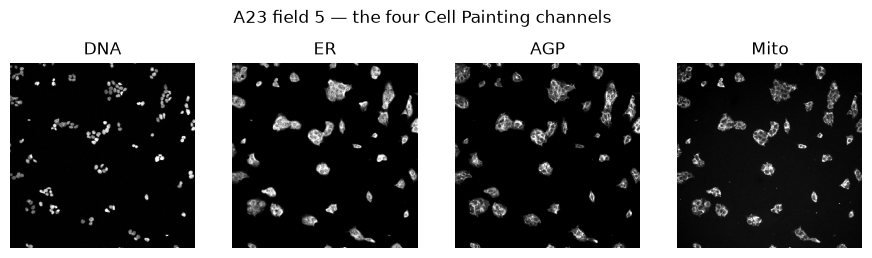

In [11]:
def disp_norm(channel: str, ref: str = "A23_F5_image") -> Normalize:
    """A shared contrast window for a channel, from one field's 2nd/99.5th percentile."""
    band = sdata[ref].sel(c=channel).data.compute()
    return Normalize(*np.percentile(band, [2, 99.5]))


fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, ch in zip(axes, CHANNELS, strict=True):
    sdata.pl.render_images("A23_F5_image", channel=ch, cmap="gray", norm=disp_norm(ch), colorbar=False).pl.show(
        ax=ax, coordinate_systems="A23", title=ch
    )
    ax.set_axis_off()
fig.suptitle("A23 field 5 — the four Cell Painting channels")
plt.show()

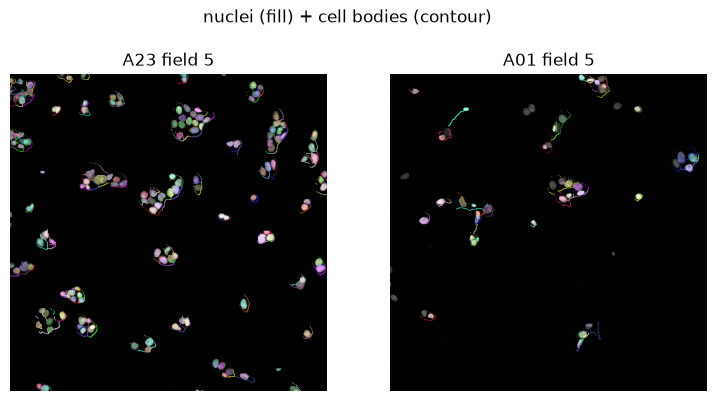

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
for ax, w in zip(axes, ["A23", "A01"], strict=True):
    (
        sdata.pl.render_images(f"{w}_F5_image", channel="DNA", cmap="gray", norm=disp_norm("DNA"), colorbar=False)
        .pl.render_labels(f"{w}_F5_cells", fill_alpha=0.0, outline_alpha=1.0, contour_px=2)
        .pl.render_labels(f"{w}_F5_nuclei", fill_alpha=0.35)
        .pl.show(ax=ax, coordinate_systems=w, title=f"{w} field 5")
    )
    ax.set_axis_off()
fig.suptitle("nuclei (fill) + cell bodies (contour)")
plt.show()

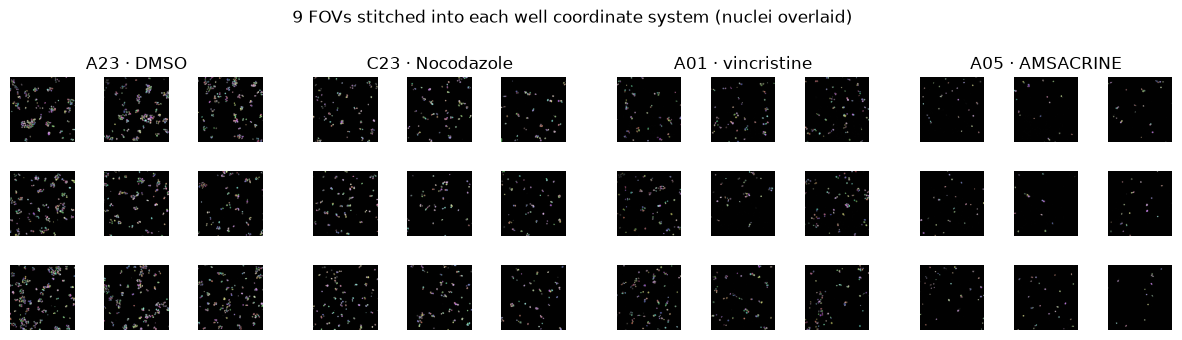

In [13]:
def well_view(w: str, kind: str = "nuclei") -> sd.SpatialData:
    ik = [k for k in sdata.images if k.startswith(f"{w}_")]
    lk = [k for k in sdata.labels if k.startswith(f"{w}_") and k.endswith(kind)]
    return sd.SpatialData(
        images={k: sdata.images[k] for k in ik},
        labels={k: sdata.labels[k] for k in lk},
        tables={"nuclei": sdata["nuclei"]},
    )


fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, w in zip(axes, WELLS, strict=True):
    lab = profiles.obs.loc[w, "compound"]
    well_view(w).pl.render_images(channel="DNA", cmap="gray", norm=disp_norm("DNA"), colorbar=False).pl.render_labels(
        fill_alpha=0.5
    ).pl.show(ax=ax, coordinate_systems=w, title=f"{w} · {lab}")
    ax.set_axis_off()
fig.suptitle("9 FOVs stitched into each well coordinate system (nuclei overlaid)")
plt.show()

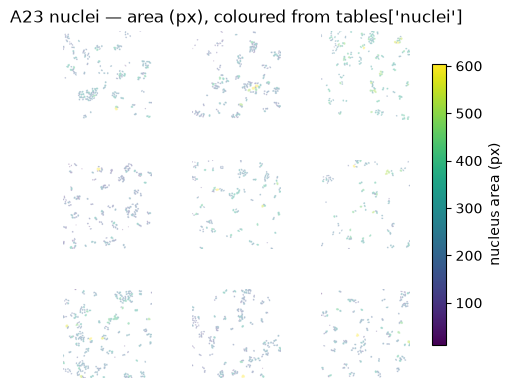

In [14]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
well_view("A23").pl.render_labels(color="area", table_name="nuclei", cmap="viridis", colorbar=False).pl.show(
    ax=ax, coordinate_systems="A23", title="A23 nuclei — area (px), coloured from tables['nuclei']"
)
ax.set_axis_off()
area = sdata["nuclei"][sdata["nuclei"].obs.well == "A23", "area"].X.ravel()
sm = plt.cm.ScalarMappable(cmap="viridis", norm=Normalize(np.percentile(area, 2), np.percentile(area, 98)))
fig.colorbar(sm, ax=ax, shrink=0.7, label="nucleus area (px)")
plt.show()

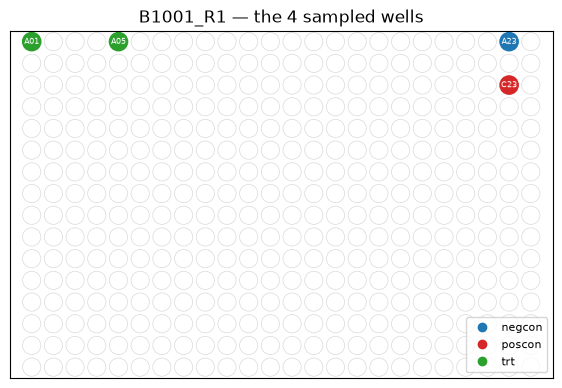

In [15]:
prof = sdata["profiles"].obs.set_index("Well")
colors = {"negcon": "tab:blue", "poscon": "tab:red", "trt": "tab:green"}
fig, ax = plt.subplots(figsize=(7, 4.6))
for r in range(16):
    for c in range(24):
        w = f"{chr(65 + r)}{c + 1:02d}"
        if w in prof.index:
            ax.add_patch(plt.Circle((c, r), 0.42, color=colors[prof.loc[w, "pert_type"]]))
            ax.annotate(w, (c, r), ha="center", va="center", fontsize=6, color="white")
        else:
            ax.add_patch(plt.Circle((c, r), 0.42, fc="none", ec="0.85", lw=0.5))
ax.set(xlim=(-1, 24), ylim=(15.5, -0.5), xticks=[], yticks=[], aspect="equal", title="B1001_R1 — the 4 sampled wells")
ax.legend(
    handles=[plt.Line2D([], [], marker="o", ls="", color=v, label=k) for k, v in colors.items()],
    loc="lower right",
    fontsize=8,
)
plt.show()

The `profiles` table is a normal AnnData — `X` is the per-plate robust z-score, `var` carries
the CellProfiler name breakdown, `layers["aggregated"]` the raw medians. A cheap morphology
signal: how many features each well shifts past `|z| > 3`. The controls (`A23` DMSO,
`C23` nocodazole) bracket the two treatments.

         compound pert_type  cell_count  strong_features
well                                                    
A01   vincristine       trt         401             1711
A05     AMSACRINE       trt          91             2055
A23          DMSO    negcon        1244              764
C23    Nocodazole    poscon         493             1569


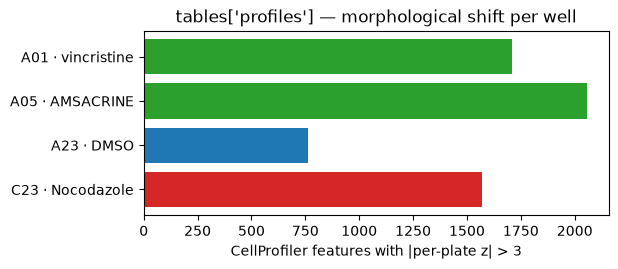

In [16]:
prof_t = sdata["profiles"]
shifted = pd.Series((np.abs(prof_t.X) > 3).sum(axis=1), index=prof_t.obs["Well"], name="|z|>3 features")
summary = prof_t.obs[["compound", "pert_type", "cell_count"]].assign(strong_features=shifted.to_numpy())
print(summary.to_string())

fig, ax = plt.subplots(figsize=(6, 2.4))
colors = {"negcon": "tab:blue", "poscon": "tab:red", "trt": "tab:green"}
ax.barh(
    [f"{w} · {c}" for w, c in zip(prof_t.obs["Well"], prof_t.obs["compound"], strict=True)],
    shifted.to_numpy(),
    color=[colors[p] for p in prof_t.obs["pert_type"]],
)
ax.set(xlabel="CellProfiler features with |per-plate z| > 3", title="tables['profiles'] — morphological shift per well")
ax.invert_yaxis()
plt.show()

## What this says about the design

* **One SpatialData per plate works.** 4 wells × 9 FOVs × 4 ch land at **~150 MB on disk**
  (`WELLS` scales it linearly) — a full 384-well plate is order 10–15 GB, dominated entirely
  by image pixels. `uint16` label masks and both feature tables are negligible.
* **Per-FOV → per-well transform: exact here.** The CV8000 records absolute stage positions,
  so each field is a pure `Translation` into its well frame and the FOVs tile with the true
  `~296 µm` gaps. Without stage metadata each FOV could only live in its own frame.
* **Per-well → plate transform: approximate.** It uses the *nominal* 4.5 mm well pitch from
  the plate spec, not a measured plate origin, so the `plate` frame is good for a well map,
  not for cross-well pixel alignment.
* **Concatenation is a naming contract**, not a merge: disjoint element keys + disjoint (or
  deliberately shared) coordinate-system names. Prefix by plate and the same `concatenate`
  call builds a multi-plate object.
* **Objects belong in `labels` + an annotating `tables` entry.** The well × feature matrix is
  one small table; a single-cell table would be the memory-heavy element (~1M rows/plate) and
  is what you would leave out of an "all plates" object.
* The segmentation here is a scikit-image stand-in — counts run ~1.5–2× the QC'd CellProfiler
  `cell_count` — but the container, the transforms, and the round-trip are the point.